In [9]:
import os

# 把 Notebook 的工作目录切换到项目根目录
os.chdir("F:/Bearing_Diagnosis")

os.getcwd()


'F:\\Bearing_Diagnosis'

In [ ]:
# 导入常用库（画图 + FFT + PCA）
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (12, 4)


In [ ]:
# 加载处理后的 CWRU 数据（从 X.npy / y.npy）
X = np.load("data/processed/X.npy")
y = np.load("data/processed/y.npy")

X.shape, y.shape


((60, 2048), (60,))

In [ ]:
# 查看类别分布（y 的统计情况）  
unique, counts = np.unique(y, return_counts=True)
dict(zip(unique, counts))


{np.int64(-1): np.int64(28),
 np.int64(1): np.int64(16),
 np.int64(2): np.int64(16)}

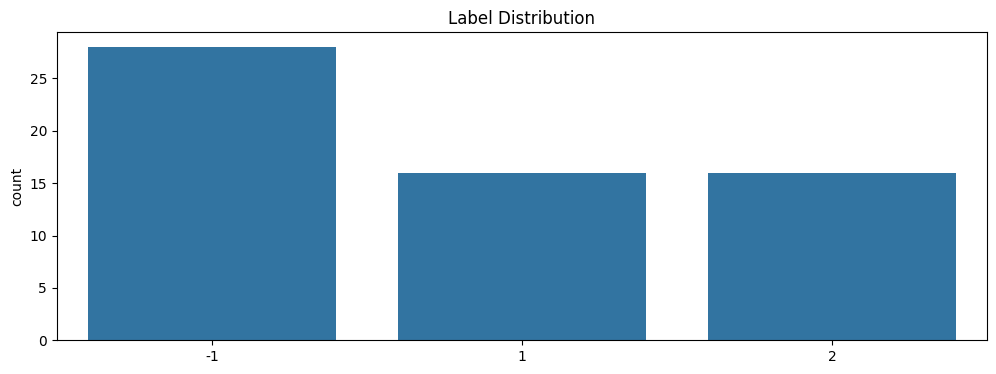

In [ ]:
# 绘制类别分布柱状图
sns.countplot(x=y)
plt.title("Label Distribution")
plt.show()


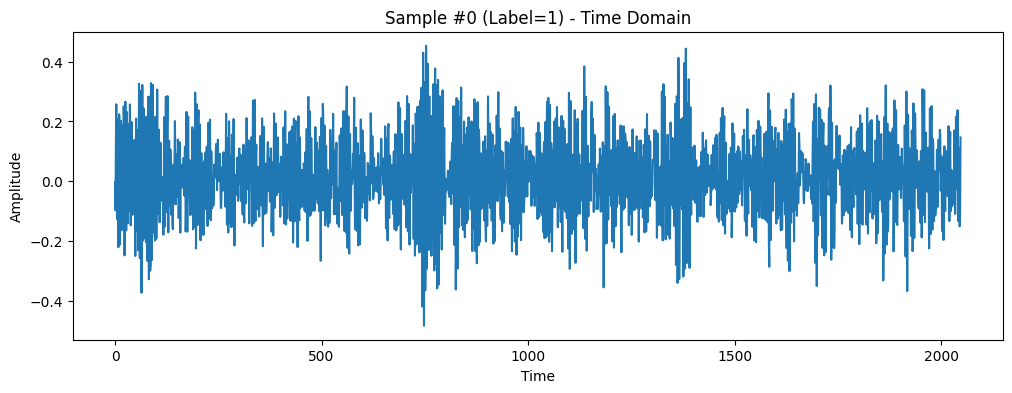

In [ ]:
# 绘制某一条样本的振动信号（时域）
idx = 0  # 随便选一条
plt.plot(X[idx])
plt.title(f"Sample #{idx} (Label={y[idx]}) - Time Domain")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()


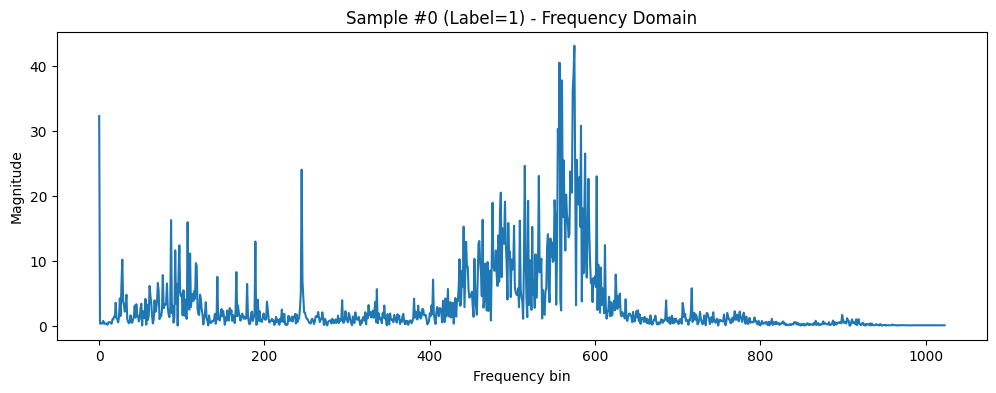

In [ ]:
# 绘制同一条样本的频域图（FFT 变换后）
signal = X[idx]
fft_vals = np.abs(fft(signal))
plt.plot(fft_vals[:len(fft_vals)//2])
plt.title(f"Sample #{idx} (Label={y[idx]}) - Frequency Domain")
plt.xlabel("Frequency bin")
plt.ylabel("Magnitude")
plt.show()


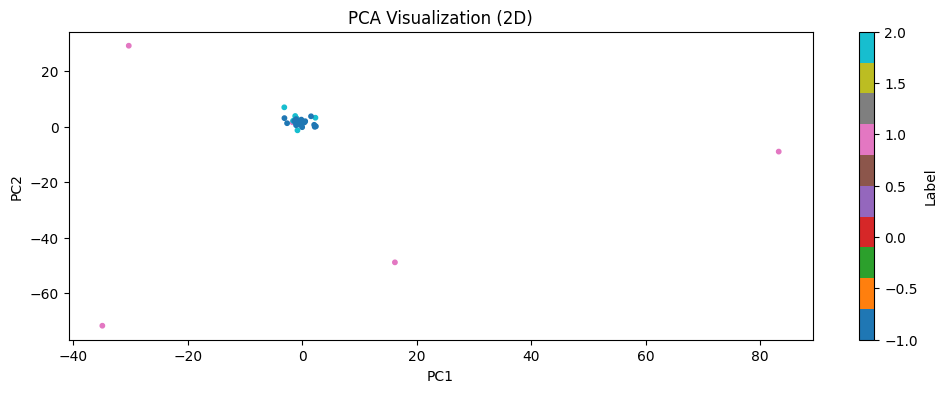

In [ ]:
# 使用 PCA 将数据降维到 2D 并可视化（全部样本）
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="tab10", s=10)
plt.title("PCA Visualization (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Label")
plt.show()


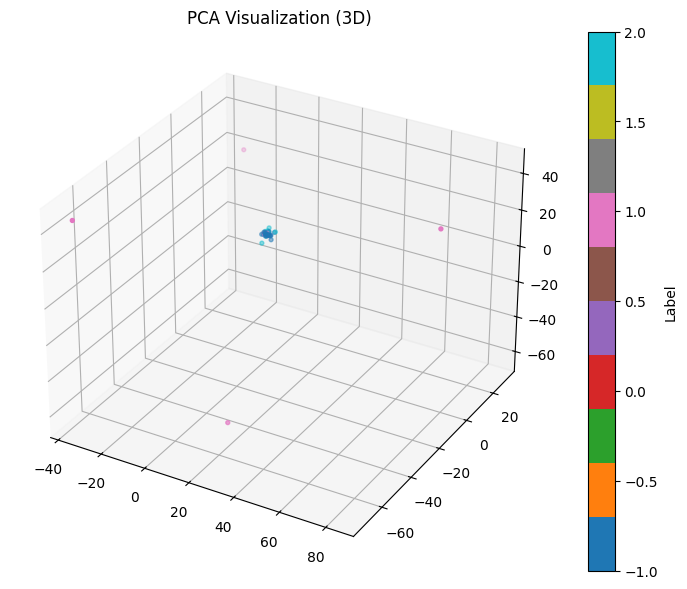

In [ ]:
# 使用 PCA 将数据降维到 3D 并可视化（全部样本）
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=y, cmap="tab10", s=8)

plt.title("PCA Visualization (3D)")
plt.colorbar(sc, label="Label")
plt.show()


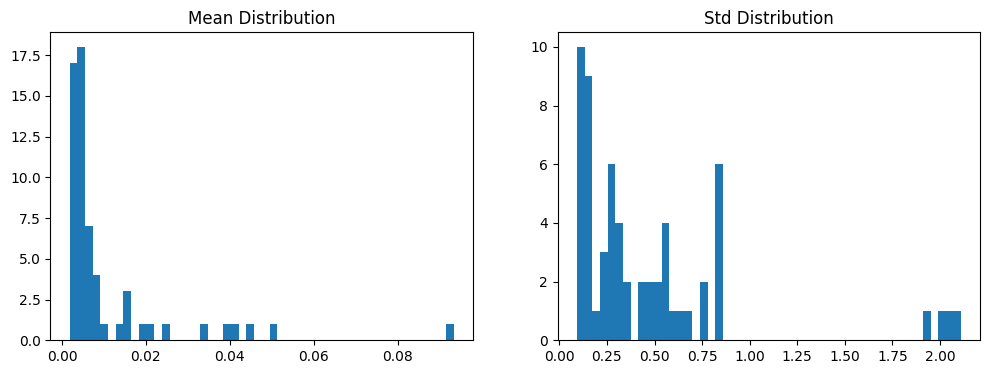

In [ ]:
# 计算并绘制每个样本的信号均值、方差等统计特征
mean_vals = X.mean(axis=1)
std_vals = X.std(axis=1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(mean_vals, bins=50)
plt.title("Mean Distribution")

plt.subplot(1,2,2)
plt.hist(std_vals, bins=50)
plt.title("Std Distribution")

plt.show()
